In [1]:
import pandas as pd

In [2]:
# https://ai.stanford.edu/~amaas/data/sentiment/

dataset = pd.read_csv('IMDB Dataset.csv')

In [3]:
dataset.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
dataset.sentiment.value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [5]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [6]:
dataset.drop_duplicates(keep='first', inplace=True)

In [7]:
dataset.shape

(49582, 2)

In [8]:
labels = { "negative" : 0, "positive" : 1}

X = dataset.review
Y = dataset.sentiment.replace(labels).to_numpy()

In [9]:
X[4]

'Petter Mattei\'s "Love in the Time of Money" is a visually stunning film to watch. Mr. Mattei offers us a vivid portrait about human relations. This is a movie that seems to be telling us what money, power and success do to people in the different situations we encounter. <br /><br />This being a variation on the Arthur Schnitzler\'s play about the same theme, the director transfers the action to the present time New York where all these different characters meet and connect. Each one is connected in one way, or another to the next person, but no one seems to know the previous point of contact. Stylishly, the film has a sophisticated luxurious look. We are taken to see how these people live and the world they live in their own habitat.<br /><br />The only thing one gets out of all these souls in the picture is the different stages of loneliness each one inhabits. A big city is not exactly the best place in which human relations find sincere fulfillment, as one discerns is the case wit

### Text Processing

In [10]:
import re
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

lemmatizer = WordNetLemmatizer()

def text_processor(text):
    
    text = text.lower()
    
    # Removing HTML Tags
    text = re.sub(r"<.+?>", "", text)
    
    # Removing URLs
    text = re.sub(r"(https?:\/\/\S+)|(www.\S+)", "", text)
    
    # Removing Puncuation and Sepcial Chars
    text = re.sub(r"[^\w\d\s]", " ", text)
    
    # Removing Spaces
    text = text.strip()
    
    # Removing Stop words
    text = [word for word in text.split() if (word not in ENGLISH_STOP_WORDS) and (len(word) > 1) ]
    text = " ".join(text)
    
    # Lemmatization {Optional}
    # text = lemmatizer.lemmatize(text)
    
    return text

In [11]:
cleaned_features = X.apply(text_processor).to_numpy()

In [12]:
cleaned_features[4]

'petter mattei love time money visually stunning film watch mr mattei offers vivid portrait human relations movie telling money power success people different situations encounter variation arthur schnitzler play theme director transfers action present time new york different characters meet connect connected way person know previous point contact stylishly film sophisticated luxurious look taken people live world live habitat thing gets souls picture different stages loneliness inhabits big city exactly best place human relations fulfillment discerns case people encounter acting good mr mattei direction steve buscemi rosario dawson carol kane michael imperioli adrian grenier rest talented cast make characters come alive wish mr mattei good luck await anxiously work'

In [13]:
cleaned_features.shape

(49582,)

In [14]:
# Visualization

# !pip install wordcloud

from wordcloud import WordCloud

cloud = WordCloud(
    max_words=150, width=1000, height=700, colormap="winter"
)
image = cloud.generate(" ".join(cleaned_features[Y==0][:1000]))

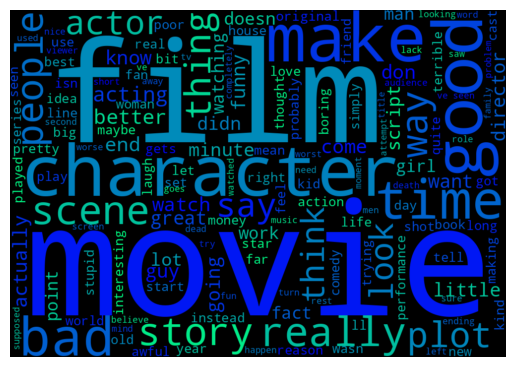

In [15]:
# Display the visualization
import matplotlib.pyplot as plt 

plt.imshow(image, interpolation='bilinear')
plt.axis('off')  # Hide the coordinate axes
plt.show()

## Vectorize or Embeddings

In [16]:
# Frequency Based [ TF-IDF ]
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(cleaned_features)

X_tfidf[0].toarray()

array([[0., 0., 0., ..., 0., 0., 0.]], shape=(1, 103546))

In [17]:
# Prediction Based [Word2Vec]

tokens = [doc.split() for doc in cleaned_features]

In [42]:
# Training custom model using our data
from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences= tokens,
    vector_size=250,
    min_count=2,
    sg = 1
)

In [18]:
# Downloading pre-trained Data
from gensim import downloader

twitter_200_model = downloader.load("glove-twitter-200")

In [43]:
import numpy as np

def vectorizer(tokens, model):
    vectors = [
        model[word] for word in tokens if word in model
    ]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    
    return np.mean(vectors, axis=0)


embeddings = np.array([
    vectorizer(token, w2v_model.wv) for token in tokens
])

In [44]:
embeddings.shape

(49582, 250)

In [22]:
# Contexualize text embeddings
from transformers import BertTokenizer, BertModel

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained("bert-base-uncased")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
tokens = tokenizer(cleaned_features[:100].tolist(), trunication=True, return_tensors='pt')
output = model(**tokens)

In [ ]:
embeddings = output.last_hidden_state.shape

## Classifying Sentiment

In [22]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score

In [24]:
logistic_model = LogisticRegression(max_iter=500, random_state=99)
svm_model = SVC(random_state=99)

In [34]:
def train_my_model(
    model, embeddings, labels, verbose = False
)-> dict:
    
    if verbose:
        print("Splitting into TrainSet (80%) and TestSet (20%) !")
        
    X_train, X_test, y_train, y_test = train_test_split(
        embeddings, labels, test_size=0.2, shuffle=True, stratify=labels, random_state=852
    )
    
    if verbose:
        print(f"Training with {model.__module__} ! ")

    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    con_matrix = confusion_matrix(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    return {
        "trained_model" : model,
        "metrics": {
            "confusion_matrix" : con_matrix,
            "accuracy_score" : accuracy,
            "f1_score" : f1
        }
    }

In [45]:
results = train_my_model(
    logistic_model, embeddings, Y.astype(int)
)
results

{'trained_model': LogisticRegression(max_iter=500, random_state=99),
 'metrics': {'confusion_matrix': array([[4307,  633],
         [ 505, 4472]]),
  'accuracy_score': 0.8852475547040436,
  'f1_score': 0.8871255703233485}}

In [46]:
results = train_my_model(
    svm_model, embeddings, Y.astype(int)
)
results

{'trained_model': SVC(random_state=99),
 'metrics': {'confusion_matrix': array([[4309,  631],
         [ 481, 4496]]),
  'accuracy_score': 0.8878693153171322,
  'f1_score': 0.889944576405384}}

In [47]:
review = "<br>Misery and Stand By Me were the best adaptations up until this one, now you can add Shawshank to that list.<br>This is simply one of the best films ever made and I know I am not the first to say that and I certainly won't be the last. The standing on the IMDb is a true barometer of that. #3 as of this date and I'm sure it could be number 1. So I'll just skip all the normal praise of the film because we all know how great it is. But let me perhaps add that what I find so fascinating about Shawshank is that Stephen King wrote it.<br><br>King is one of the best writers in the world. Books like IT and the Castle Rock series are some of the greatest stories ever told. But his best adaptations are always done by the best directors. The Shining was brilliantly interpreted by Kubrick and of course the aforementioned Misery and Stand By Me are both by Rob Reiner. Now Frank Darabont comes onto the scene and makes arguably the best King film ever. He seems to understand what King wants to say and he conveys that beautifully. <br><br>What makes this film one of the best ever made is the message it conveys. It is one of eternal hope. Andy Dufresne, played by Tim Robbins, has been sent to prison for a crime he did not commit. But he never loses hope. He never gives up his quest to become a free man again. His years of tenacity, patience and wits keep him not only sane, but it gives his mind and a spirit a will to live. This film has a different feel to it. There has never been anything like it before and I don't know if there will again.<br><br>I'm not going to say any more about this film, it has already been said, but just suffice to say that I am glad that Forrest Gump won best picture in 94. I would have been equally glad if Pulp Fiction or Shawshank would have won. It is that good of a movie and one that will be appreciated for years to come."
print(review)

<br>Misery and Stand By Me were the best adaptations up until this one, now you can add Shawshank to that list.<br>This is simply one of the best films ever made and I know I am not the first to say that and I certainly won't be the last. The standing on the IMDb is a true barometer of that. #3 as of this date and I'm sure it could be number 1. So I'll just skip all the normal praise of the film because we all know how great it is. But let me perhaps add that what I find so fascinating about Shawshank is that Stephen King wrote it.<br><br>King is one of the best writers in the world. Books like IT and the Castle Rock series are some of the greatest stories ever told. But his best adaptations are always done by the best directors. The Shining was brilliantly interpreted by Kubrick and of course the aforementioned Misery and Stand By Me are both by Rob Reiner. Now Frank Darabont comes onto the scene and makes arguably the best King film ever. He seems to understand what King wants to say

In [48]:
clean_review = text_processor(review)

In [50]:
tokens = [clean_review.split(" ")]

embeddings = np.array([
    vectorizer(token, w2v_model.wv) for token in tokens
])

In [53]:
best_model = results['trained_model']

best_model.predict(embeddings)

array([1])

## Saving the model and vectorizer

In [54]:
import joblib

In [55]:
joblib.dump(
    w2v_model, "Word2Vec_imdb_250.joblib"
)

['Word2Vec_imdb_250.joblib']

In [57]:
joblib.dump(
    best_model, "SVM_model.joblib", compress=3
)

['SVM_model.joblib']